# Часть 1 Бустинг (5 баллов)

Султанбекова Орнелла ИАД-9

В этой части будем предсказывать зарплату data scientist-ов в зависимости  от ряда факторов с помощью градиентного бустинга.

В датасете есть следующие признаки:



* work_year: The number of years of work experience in the field of data science.

* experience_level: The level of experience, such as Junior, Senior, or Lead.

* employment_type: The type of employment, such as Full-time or Contract.

* job_title: The specific job title or role, such as Data Analyst or Data Scientist.

* salary: The salary amount for the given job.

* salary_currency: The currency in which the salary is denoted.

* salary_in_usd: The equivalent salary amount converted to US dollars (USD) for comparison purposes.

* employee_residence: The country or region where the employee resides.

* remote_ratio: The percentage of remote work offered in the job.

* company_location: The location of the company or organization.

* company_size: The company's size is categorized as Small, Medium, or Large.

In [1]:
import pandas as pd

df = pd.read_csv("ds_salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


## Задание 1 (0.5 балла) Подготовка



*   Разделите выборку на train, val, test (80%, 10%, 10%)
*   Выдерите salary_in_usd в качестве таргета
*   Найдите и удалите признак, из-за которого возможен лик в данных


In [2]:
from sklearn.model_selection import train_test_split

df = df.drop(['salary', 'salary_currency'], axis=1)
# так как 'salary' и 'salary_currency' дают столбец 'salary_in_usd'
X = df.drop('salary_in_usd', axis=1)
y = df['salary_in_usd']

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test_full, y_test_full, test_size=0.5, random_state=42)

## Задание 2 (0.5 балла) Линейная модель


*   Закодируйте категориальные  признаки с помощью OneHotEncoder
*   Обучите модель линейной регрессии
*   Оцените  качество через MAPE и RMSE


In [3]:
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder

categorical_features = X.select_dtypes(include='object').columns.tolist()

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_ohe = ohe.fit_transform(X_train_full[categorical_features])
X_val_ohe = ohe.transform(X_val[categorical_features])
X_test_ohe = ohe.transform(X_test[categorical_features])

lr = LinearRegression()
lr.fit(X_train_ohe, y_train_full)

y_pred = lr.predict(X_test_ohe)

print('MAPE: ', mean_absolute_percentage_error(y_test, y_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, y_pred)))

MAPE:  0.36938631913384284
RMSE:  51729.27140478532


## Задание 3 (0.5 балла) XGboost

Начнем с библиотеки xgboost.

Обучите модель `XGBRegressor` на тех же данных, что линейную модель, подобрав оптимальные гиперпараметры (`max_depth, learning_rate, n_estimators, gamma`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [8]:
from xgboost.sklearn import XGBRegressor
import time

params = {
    'max_depth' : 5,
    'learning_rate' : 0.2,
    'n_estimators' : 300,
    'gamma' : 0.2,
    'reg_alpha': 45
}

xgb = XGBRegressor(**params)

start = time.time()
xgb.fit(X_train_ohe, y_train_full)
end = time.time()
print('Время обучения: ', end - start)

start = time.time()
y_pred = xgb.predict(X_val_ohe)
end = time.time()
print('Время предсказания: ', end - start)

Время обучения:  1.1608161926269531
Время предсказания:  0.00888681411743164


In [9]:
print('MAPE: ', mean_absolute_percentage_error(y_val, y_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_val, y_pred)))

MAPE:  0.36028939485549927
RMSE:  45614.67974238118


## Задание 4 (1 балл) CatBoost

Теперь библиотека CatBoost.

Обучите модель `CatBoostRegressor`, подобрав оптимальные гиперпараметры (`depth, learning_rate, iterations`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [10]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [11]:
from catboost import CatBoostRegressor

params = {
    'depth' : 6,
    'learning_rate' : 0.2,
    'iterations' : 260,
    'verbose': False,
    'random_seed': 42
}

cat = CatBoostRegressor(**params)

start = time.time()
cat.fit(X_train_ohe, y_train_full)
end = time.time()
print('Время обучения: ', end - start)

start = time.time()
y_pred = cat.predict(X_val_ohe)
end = time.time()
print('Время предсказания: ', end - start)

Время обучения:  0.5106148719787598
Время предсказания:  0.0035810470581054688


In [12]:
print('MAPE: ', mean_absolute_percentage_error(y_val, y_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_val, y_pred)))

MAPE:  0.3743369415289019
RMSE:  45134.22534393056


Для применения catboost моделей не обязательно сначала кодировать категориальные признаки, модель может кодировать их сама. Обучите catboost с подбором оптимальных гиперпараметров снова, используя pool для передачи данных в модель с указанием какие признаки категориальные, а какие нет с помощью параметра cat_features. Оцените качество и время. Стало ли лучше?

In [15]:
from catboost import Pool

train_pool = Pool(X_train_full, y_train_full, cat_features=categorical_features)
val_pool = Pool(X_val, y_val, cat_features=categorical_features)
test_pool = Pool(X_test, y_test, cat_features=categorical_features)

cat_2 = CatBoostRegressor(**params)

start = time.time()
cat_2.fit(train_pool)
end = time.time()
print('Время обучения: ', end - start)

start = time.time()
y_pred = cat_2.predict(val_pool)
end = time.time()
print('Время предсказания: ', end - start)

print('MAPE: ', mean_absolute_percentage_error(y_val, y_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_val, y_pred)))

Время обучения:  1.2914843559265137
Время предсказания:  0.0014348030090332031
MAPE:  0.39961214651688864
RMSE:  46335.868285928904


**Ответ:** видим, что обучение заняло больше времени, однако, качество модели почти не изменилось

## Задание 5 (0.5 балла) LightGBM

И наконец библиотека LightGBM - используйте `LGBMRegressor`, снова подберите гиперпараметры, оцените качество и скорость.


In [17]:
from lightgbm import LGBMRegressor


params = {
    'max_depth' : 6,
    'learning_rate' : 0.03,
    'n_estimators' : 500,
    'num_leaves': 50,
    'verbose': -1,
    'min_data_in_leaf': 30,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 1.0,
    'reg_lambda': 5.0,
    'random_state': 42
}

lgbmr = LGBMRegressor(**params)

start = time.time()
lgbmr.fit(X_train_ohe, y_train_full)
end = time.time()
print('Время обучения: ', end - start)

start = time.time()
y_pred = lgbmr.predict(X_val_ohe)
end = time.time()
print('Время предсказания: ', end - start)

Время обучения:  0.2638850212097168
Время предсказания:  0.018607378005981445


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [18]:
print('MAPE: ', mean_absolute_percentage_error(y_val, y_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_val, y_pred)))

MAPE:  0.399590147404836
RMSE:  46365.80353350499


## Задание 6 (2 балла) Сравнение и выводы

Сравните модели бустинга и сделайте про них выводы, какая из моделей показала лучший/худший результат по качеству, скорости обучения и скорости предсказания? Как отличаются гиперпараметры для разных моделей?

**Ответ:** если сравнивать результаты, то видно, что наибольшее время обучения требуется модели CatBoost со встроенной обработкой категориальных признаков. Это связано с тем, что алгоритм на лету просчитывает сложные комбинации категорий и применяет защитные перестановки. Что насчёт качества, то лучше всего показатели у CatBoost с уже зараннее закодированными признаками (минимальные значения MAPE и RMSE).

Самым быстрым на этапе обучения оказался LightGBM. Его высокая скорость обусловлена оптимизированным ростом деревьев по листьям (leaf-wise) и эффективным сканированием данных. При этом без глубокой настройки гиперпараметров LightGBM показал наихудшее качество среди всех моделей, оказавшись склонным к досрочной остановке ветвления и переобучению.

Время предсказания у всех моделей +- одинаковое. Они все довольно быстро справляются с данной задачей.

# Часть 2 Кластеризация (5 баллов)

Будем работать с данными о том, каких исполнителей слушают пользователи музыкального сервиса.

Каждая строка таблицы - информация об одном пользователе. Каждый столбец - это исполнитель (The Beatles, Radiohead, etc.)

Для каждой пары (пользователь, исполнитель) в таблице стоит число - доля прослушивания этого исполнителя этим пользователем.


In [19]:
import pandas as pd
ratings = pd.read_excel("https://github.com/evgpat/edu_stepik_rec_sys/blob/main/datasets/sample_matrix.xlsx?raw=true", engine='openpyxl')
ratings.head()

,user,the beatles,radiohead,deathcab for cutie,coldplay,modest mouse,sufjan stevens,dylan. bob,red hot clili peppers,pink fluid,...,municipal waste,townes van zandt,curtis mayfield,jewel,lamb,michal w. smith,群星,agalloch,meshuggah,yellowcard
0,0,NaN,0.020417,NaN,NaN,NaN,NaN,NaN,0.030496,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,0.184962,0.024561,NaN,NaN,0.136341,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,0.028635,NaN,NaN,NaN,0.024559,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0.043529,0.086281,0.034590,0.016712,0.015935,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Будем строить кластеризацию исполнителей: если двух исполнителей слушало много людей примерно одинаковую долю своего времени (то есть векторы близки в пространстве), то, возможно исполнители похожи. Эта информация может быть полезна при построении рекомендательных систем.

## Задание 1 (0.5 балла) Подготовка

Транспонируем матрицу ratings, чтобы по строкам стояли исполнители.

In [20]:
ratings_t = ratings.T
ratings_t.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
user,0.000000,1.000000,2.000000,3.0,4.000000,5.000000,6.0,7.0,8.000000,9.000000,...,4990.000000,4991.0,4992.000000,4993.000000,4994.000000,4995.000000,4996.0,4997.000000,4998.0,4999.000000
the beatles,NaN,NaN,NaN,NaN,0.043529,NaN,NaN,NaN,0.093398,0.017621,...,NaN,NaN,0.121169,0.038168,0.007939,0.017884,NaN,0.076923,NaN,NaN
radiohead,0.020417,0.184962,NaN,NaN,0.086281,0.006322,NaN,NaN,NaN,0.019156,...,0.017735,NaN,NaN,NaN,0.011187,NaN,NaN,NaN,NaN,NaN
deathcab for cutie,NaN,0.024561,0.028635,NaN,0.034590,NaN,NaN,NaN,NaN,0.013349,...,0.121344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027893
coldplay,NaN,NaN,NaN,NaN,0.016712,NaN,NaN,NaN,NaN,NaN,...,0.217175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Выкиньте строку под названием `user`.

In [21]:
ratings_t = ratings_t.iloc[1:]
ratings_t.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
the beatles,NaN,NaN,NaN,NaN,0.043529,NaN,NaN,NaN,0.093398,0.017621,...,NaN,NaN,0.121169,0.038168,0.007939,0.017884,NaN,0.076923,NaN,NaN
radiohead,0.020417,0.184962,NaN,NaN,0.086281,0.006322,NaN,NaN,NaN,0.019156,...,0.017735,NaN,NaN,NaN,0.011187,NaN,NaN,NaN,NaN,NaN
deathcab for cutie,NaN,0.024561,0.028635,NaN,0.034590,NaN,NaN,NaN,NaN,0.013349,...,0.121344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027893
coldplay,NaN,NaN,NaN,NaN,0.016712,NaN,NaN,NaN,NaN,NaN,...,0.217175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
modest mouse,NaN,NaN,NaN,NaN,0.015935,NaN,NaN,NaN,NaN,0.030437,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


В таблице много пропусков, так как пользователи слушают не всех-всех исполнителей, чья музыка представлена в сервисе, а некоторое подмножество (обычно около 30 исполнителей)


Доля исполнителя в музыке, прослушанной  пользователем, равна 0, если пользователь никогда не слушал музыку данного музыканта, поэтому заполните пропуски нулями.



In [22]:
ratings_t = ratings_t.fillna(0)
ratings_t.sample()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
clutch,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Задание 2 (0.5 балла) Первая кластеризация

Примените KMeans с 5ю кластерами, сохраните полученные лейблы

In [23]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=5, random_state=42)
km.fit(ratings_t)
labels = km.labels_

Выведите размеры кластеров. Полезной ли получилась кластеризация? Почему KMeans может выдать такой результат?

In [24]:
uniq, counts = np.unique(labels, return_counts=True)
print(counts)

[115   1   1 882   1]


**Ответ:** видим, что есть кластеры, где всего один объект. скорее всего это выбросы, то есть исполнители, которые не очень популярны. а есть кластер, где 882 (почти все). в итоге получаем, что данная кластеризация бесполезна, так как есть один гигант и несколько мелких групп.

## Задание 3 (0.5 балла) Объяснение результатов

При кластеризации получилось $\geq 1$ кластера размера 1. Выведите исполнителей, которые составляют такие кластеры. Среди них должна быть группа The Beatles.

In [25]:
artist_names = ratings_t.index
not_popular = uniq[counts == 1]
single_artist = []

for idx, cluster in enumerate(labels):
    if cluster in not_popular:
        artist_name = artist_names[idx]
        single_artist.append(artist_name)

print(single_artist)

['the beatles', 'niИ', '日dir en grey']


Изучите данные, почему именно The Beatles выделяется?

Подсказка: посмотрите на долю пользователей, которые слушают каждого исполнителя, среднюю долю прослушивания.

In [26]:
rating_sum = ratings_t.sum(axis=1).sort_values(ascending=False)
rating_sum

,0
the beatles,91.844883
radiohead,59.256073
deathcab for cutie,32.716688
niИ,32.351575
coldplay,30.151904
...,...
plus-44,1.075778
finger eleven,1.062241
jenny lewis with the watson twins,1.054159
jet,0.997300


In [27]:
rating_sum.mean()

np.float64(4.966)

**Ответ:** KMeans основан на Евклидовом расстоянии. The Beatles — это "выброс" в плане популярности. Их слушают почти все, и доля прослушивания у них выше. В пространстве Евклида они находятся очень далеко от непопулярных групп (так среднее это 4.966, а у Beatles - 91.84), поэтому алгоритм выделяет их в отдельный кластер.

## Задание 4 (0.5 балла) Улучшение кластеризации

Попытаемся избавиться от этой проблемы: нормализуйте данные при помощи `normalize`.

In [28]:
from sklearn.preprocessing import normalize

ratings_norm = normalize(ratings_t)

km = KMeans(n_clusters=5, random_state=42)
km.fit(ratings_norm)
labels = km.labels_

Примените KMeans с 5ю кластерами на преобразованной матрице, посмотрите на их размеры. Стало ли лучше? Может ли кластеризация быть полезной теперь?

In [29]:
uniq, counts = np.unique(labels, return_counts=True)
print(counts)

[ 79 162 133 140 486]


**Ответ** кластеризация несомненно стала лучше, так как есть пять кластеров, в каждом из которых есть немало объектов. однако, всё также есть доминирующий кластер, где 486 объектов

## Задание 5 (1 балл) Центроиды

Выведите для каждого кластера названия топ-10 исполнителей, ближайших к центроиду по косинусной мере. Проинтерпретируйте результат. Что можно сказать о смысле кластеров?

In [30]:
from scipy.spatial.distance import cosine

artist_names = ratings_t.index
centroids = km.cluster_centers_

for i in range(5):
    centr = centroids[i]
    dists = []

    for idx, row in enumerate(ratings_norm):
        dist = cosine(centr, row)
        name = artist_names[idx]
        dists.append((name, dist))

    top_10 = sorted(dists, key=lambda x: x[1])[:10]

    print(f'Cluster {i}:')
    for artist, dist in top_10:
        print(f"\t{artist} (dist: {dist:.4f})")


Cluster 0:
	nas (dist: 0.4639)
	jay-z (dist: 0.4955)
	kanye west (dist: 0.5201)
	lupe the gorilla (dist: 0.5839)
	a tribe called quest (dist: 0.5867)
	the roots featuring d'angelo (dist: 0.5938)
	gangstarr (dist: 0.6280)
	little brother (dist: 0.6291)
	lil' wayne (dist: 0.6326)
	murs and 9th wonder (dist: 0.6352)
Cluster 1:
	fall out boy (dist: 0.6349)
	the all-americian rejects (dist: 0.6560)
	paramore (dist: 0.6587)
	kelly clarkson (dist: 0.6644)
	john mayer (dist: 0.6750)
	the fray (dist: 0.6752)
	maroon5 (dist: 0.6883)
	dashboard confesssional (dist: 0.6910)
	somethings corporate (dist: 0.7105)
	coldplay (dist: 0.7115)
Cluster 2:
	brand new (dist: 0.6308)
	blink-182 (dist: 0.6555)
	alkaline trio (dist: 0.6632)
	against me! (dist: 0.6656)
	underoath (dist: 0.7000)
	descendents (dist: 0.7011)
	new found glory (dist: 0.7021)
	less than jake (dist: 0.7055)
	thrice (dist: 0.7062)
	chiodos (dist: 0.7124)
Cluster 3:
	the beatles (dist: 0.6203)
	the rolling stones (dist: 0.6235)
	dylan. bo

**Ответ:** интерпретация каждого из 5 полученных кластеров:

Кластер 0: Хип-хоп / Рэп

Кластер 1: Поп-рок / Популярная музыка 2000-х

Кластер 2: Альтернативный рок / Поп-панк

Кластер 3: Классический рок / Ретро / Интеллектуальная классика

Кластер 4: Инди-рок

## Задание 6 (1 балл) Визуализация

Хотелось бы как-то визуализировать полученную кластеризацию. Постройте точечные графики `plt.scatter` для нескольких пар признаков исполнителей, покрасив точки в цвета кластеров. Почему визуализации получились такими? Хорошо ли они отражают разделение на кластеры? Почему?

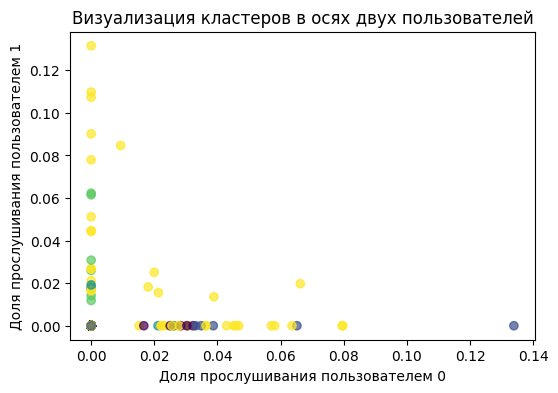

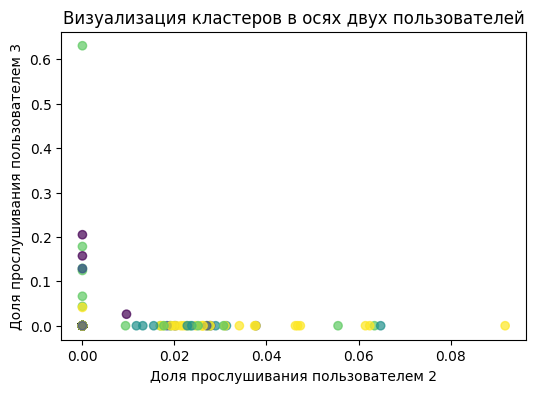

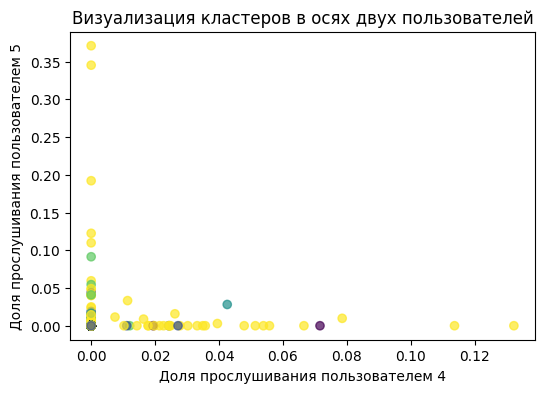

In [31]:
import matplotlib.pyplot as plt

pairs = [(0, 1), (2, 3), (4, 5)]

for x_idx, y_idx in pairs:
    plt.figure(figsize=(6, 4))
    plt.scatter(
        ratings_norm[:, x_idx],
        ratings_norm[:, y_idx],
        c=labels,
        alpha=0.7,
        cmap='viridis'
    )
    plt.xlabel(f'Доля прослушивания пользователем {x_idx}')
    plt.ylabel(f'Доля прослушивания пользователем {y_idx}')
    plt.title(f'Визуализация кластеров в осях двух пользователей')
    plt.show()
    print()

**Ответ:** визуализации получились в форме буквы L из-за высокой разреженности данных (большинство артистов не прослушивались данными пользователями). Разделение на кластеры отражено плохо, так как два случайно выбранных признака (пользователя) не содержат достаточно информации о структуре данных, которая распределена по сотням измерений

Для визуализации данных высокой размерности существует метод t-SNE (стохастическое вложение соседей с t-распределением). Данный метод является нелинейным методом снижения размерности: каждый объект высокой размерности будет моделироваться объектов более низкой (например, 2) размерности таким образом, чтобы похожие объекты моделировались близкими, непохожие - далекими с большой вероятностью.

Примените `TSNE` из библиотеки `sklearn` и визуализируйте полученные объекты, покрасив их в цвета их кластеров

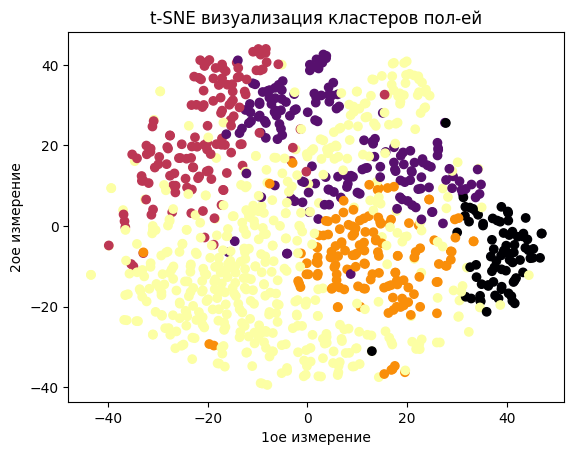

In [32]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=40, random_state=42)
embeddings = tsne.fit_transform(ratings_norm)

plt.scatter(embeddings[:, 0], embeddings[:, 1], c=labels, cmap='inferno')
plt.xlabel('1ое измерение')
plt.ylabel('2ое измерение')
plt.title('t-SNE визуализация кластеров пол-ей')
plt.show()

## Задание 7 (1 балл) Подбор гиперпараметров

Подберите оптимальное количество кластеров (максимум 100 кластеров) с использованием индекса Силуэта. Зафиксируйте `random_state=42`

In [33]:
from sklearn.metrics import silhouette_score

best_k = None
best_score = -1

for k in range(2, 101):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(ratings_norm)
    labels = km.labels_
    score = silhouette_score(ratings_norm, labels)
    if score > best_score:
        best_score = score
        best_k = k

print(f"Лучшее кол-во кластеров: {best_k}, индекс Силуэта: {best_score}")

Лучшее кол-во кластеров: 98, индекс Силуэта: 0.01332710844154191


Выведите исполнителей, ближайших с центроидам (аналогично заданию 5). Как соотносятся результаты? Остался ли смысл кластеров прежним? Расскажите про смысл 1-2 интересных кластеров, если он изменился и кластеров слишком много, чтобы рассказать про все.

In [35]:
km = KMeans(n_clusters=best_k, random_state=42)
km.fit(ratings_norm)

artist_names = ratings_t.index
centroids = km.cluster_centers_

for i in range(best_k):
    centr = centroids[i]
    dists = []

    for idx, row in enumerate(ratings_norm):
        dist = cosine(centr, row)
        name = artist_names[idx]
        dists.append((name, dist))

    top_10 = sorted(dists, key=lambda x: x[1])[:10]

    print(f'Cluster {i}:')
    for artist, dist in top_10:
        print(f"  {artist} (dist: {dist:.4f})")

Cluster 0:
  dr. dre (dist: 0.4512)
  the faint (dist: 0.5231)
  violent femmes (dist: 0.5418)
  margot and the nuclear so and sos (dist: 0.5424)
  owen (dist: 0.5523)
  the bloodhound gang (dist: 0.5694)
  cursive (dist: 0.8348)
  van hallen (dist: 0.8534)
  bright eyes (dist: 0.8848)
  ironand wine (dist: 0.9105)
Cluster 1:
  john mayer (dist: 0.4701)
  matt nathanson (dist: 0.4956)
  gavin degraw (dist: 0.5621)
  jason mraz (dist: 0.5765)
  ray lamontagne (dist: 0.5923)
  joshua radin (dist: 0.5977)
  sara bareilles (dist: 0.6117)
  augustana (dist: 0.6195)
  maroon5 (dist: 0.6517)
  o.a.r. (dist: 0.7123)
Cluster 2:
  white stripes (dist: 0.4761)
  beck (dist: 0.6074)
  the raconteurs (dist: 0.6085)
  spoon (dist: 0.6096)
  the pixies (dist: 0.6298)
  the strokes (dist: 0.6440)
  the flaming lips (dist: 0.6574)
  cake (dist: 0.6664)
  black rebel motorcycle club (dist: 0.6728)
  gorillaz (dist: 0.6790)
Cluster 3:
  fugazi (dist: 0.4639)
  jawbreaker (dist: 0.5402)
  sleater-kinney (

**Ответ:** 6 кластер - эра альтернативного металла, 17 кластер -  пост-панк и готик-рок. Опять объеденение произошло по жанру.

Сделайте t-SNE визуализацию полученной кластеризации.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


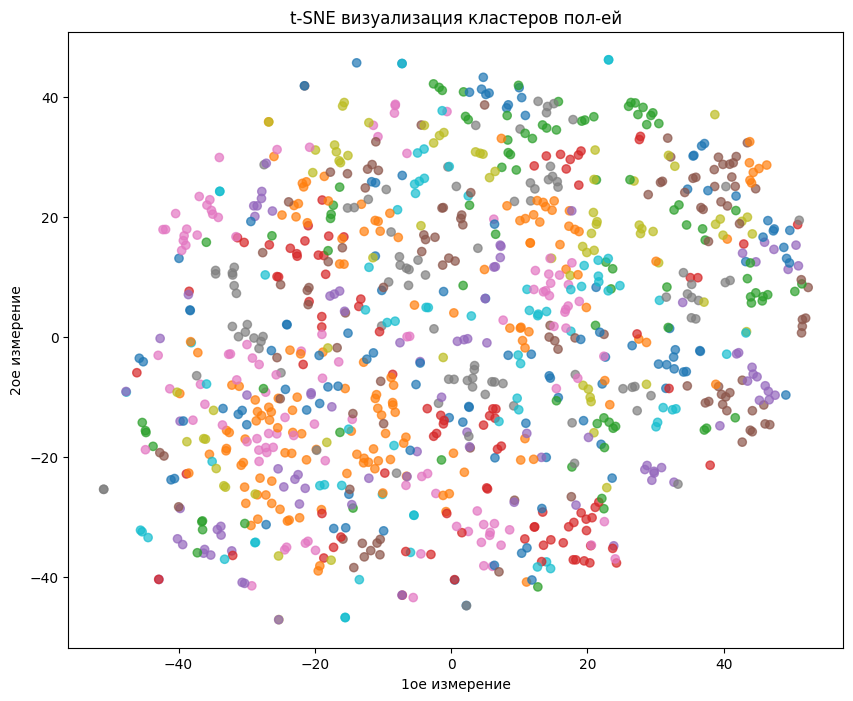

In [36]:
tsne = TSNE(n_components=2, random_state=42, perplexity=25, n_iter=1000)
embedded = tsne.fit_transform(ratings_norm)
plt.figure(figsize=(10, 8))
plt.scatter(embedded[:, 0], embedded[:, 1], c=km.labels_, cmap='tab10', alpha=0.7)
plt.xlabel('1ое измерение')
plt.ylabel('2ое измерение')
plt.title('t-SNE визуализация кластеров пол-ей')
plt.show()

Если кластеров получилось слишком много и визуально цвета плохо отличаются, покрасьте только какой-нибудь интересный кластер из задания выше (`c = (labels == i)`). Хорошо ли этот кластер отражается в визуализации?

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


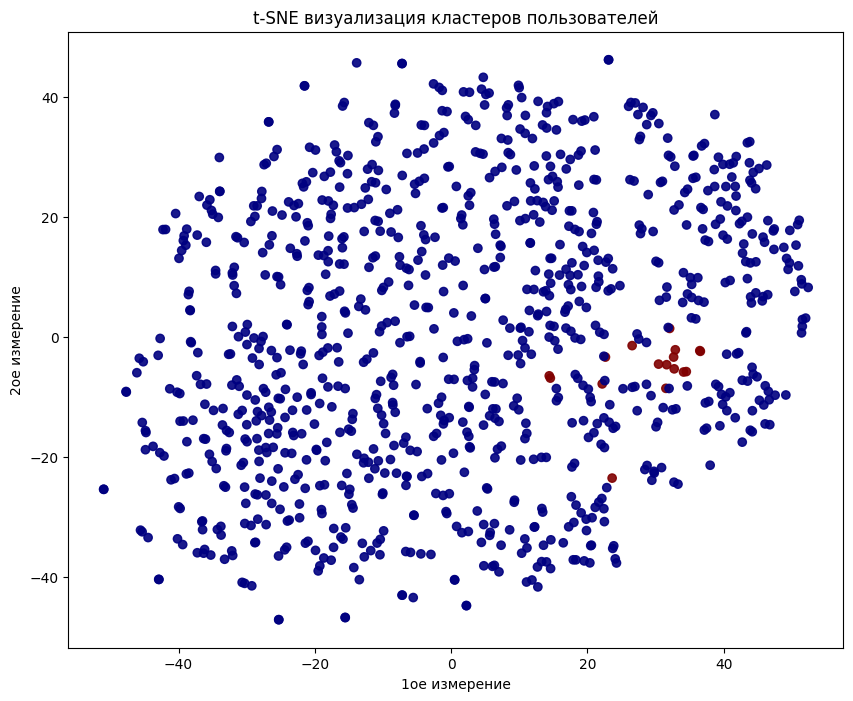

In [37]:
tsne = TSNE(n_components=2, random_state=42, perplexity=25, n_iter=1000)
embedded = tsne.fit_transform(ratings_norm)
plt.figure(figsize=(10, 8))
plt.scatter(embedded[:, 0], embedded[:, 1], c=(km.labels_==6), cmap='jet', alpha=0.9)
plt.xlabel('1ое измерение')
plt.ylabel('2ое измерение')
plt.title('t-SNE визуализация кластеров пользователей')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


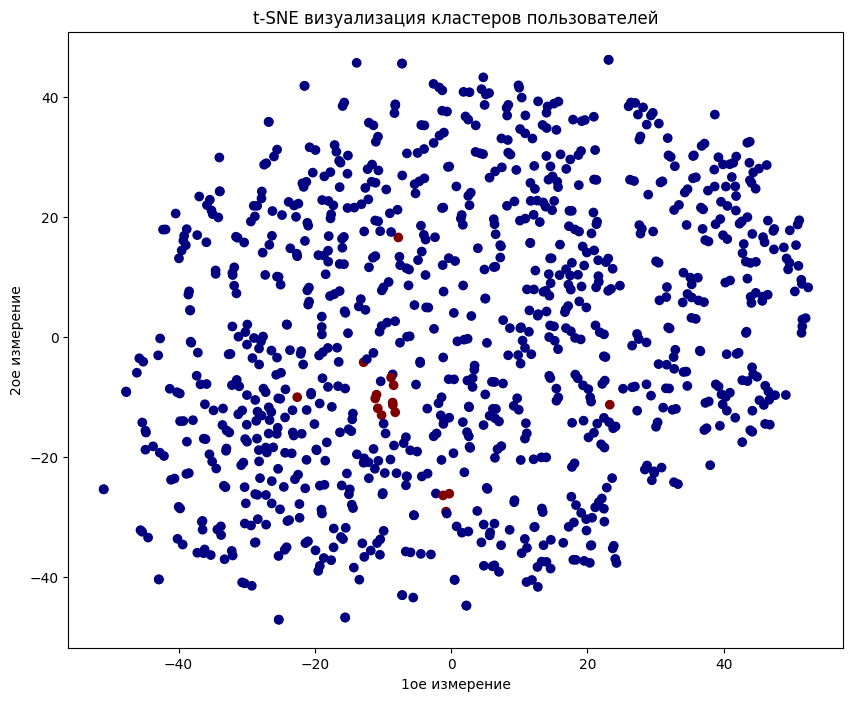

In [38]:
tsne = TSNE(n_components=2, random_state=42, perplexity=25, n_iter=1000)
embedded = tsne.fit_transform(ratings_norm)
plt.figure(figsize=(10, 8))
plt.scatter(embedded[:, 0], embedded[:, 1], c=(km.labels_==17), cmap='jet')
plt.xlabel('1ое измерение')
plt.ylabel('2ое измерение')
plt.title('t-SNE визуализация кластеров пользователей')
plt.show()

**Ответ:** видим, что для i=6 и i=17 кластеры выбраны в целом неплохо, но есть пара точек-выбросов.